# EXPERIMENT: 30-Day Next-Purchase Prediction

## SECTION 1 � Experiment Definition

**Experiment:** 30-Day Next-Purchase Prediction
**Target:** `TARGET_next_purchase_30d`

**Objective:**
Predict whether a customer will make at least one purchase within 30 days after the observation date.

**Business interpretation:**
"If Aegis knows everything available at observation time T, can it predict whether this customer will purchase within the next 30 days?"

**Definitions:**
- **Prediction Unit:** customer + observation_date
- **Target Definition:** 1 if `TARGET_next_purchase_30d` is true, 0 otherwise
- **Train/Validation/Test Strategy:** Chronological split. Train on past, validate on near future, test on far future.
- **Leakage Policy:** STRICT. Features strictly from <= observation_date. No FUTURE target leakage.
- **Success Criteria:** Outperform simple RFM baseline on PR-AUC and Top 10% Business Lift.


## SECTION 2 � Environment & Configuration

In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib
import os
import json
from pathlib import Path

from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.metrics import (roc_auc_score, average_precision_score, precision_score, 
                             recall_score, f1_score, accuracy_score, brier_score_loss, 
                             log_loss, confusion_matrix)
from sklearn.model_selection import ParameterGrid
from sklearn.calibration import calibration_curve
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline

try:
    import xgboost as xgb
    XGB_AVAILABLE = True
except ImportError:
    XGB_AVAILABLE = False
    print("XGBoost unavailable in current environment.")

RANDOM_STATE = 42

# Project paths
BASE_DIR = Path("../../..").resolve()
DATA_DIR = BASE_DIR / "prepared/online_retail_ii/temporal"
EXP_DIR = Path(".")

## SECTION 3 � Load Temporal Dataset

In [27]:
dataset_path = r"C:\Users\ACER\OneDrive\Desktop\Projects\Customer-Intelligence-Platform\backend\training\prepared\online_retail_ii\temporal\temporal_dataset.parquet"
splits_path = r"C:\Users\ACER\OneDrive\Desktop\Projects\Customer-Intelligence-Platform\backend\training\prepared\online_retail_ii\temporal\dataset_splits.parquet"

df = pd.read_parquet(dataset_path)
splits = pd.read_parquet(splits_path)

# Validate structure
assert 'TARGET_next_purchase_30d' in df.columns, "Target missing"
assert df.duplicated(subset=['customer_id', 'observation_date']).sum() == 0, "Duplicate observations found"
assert 'split' in splits.columns, "Split column missing"

# FIX: Added 'split' to the merge keys so pandas doesn't create split_x and split_y
df = df.merge(splits[['customer_id', 'observation_date', 'split']], on=['customer_id', 'observation_date', 'split'], how='inner')

print(f"Total Rows: {len(df)}")
print(f"Unique Customers: {df['customer_id'].nunique()}")
print(f"Split Distribution:\n{df['split'].value_counts()}")

Total Rows: 71647
Unique Customers: 5247
Split Distribution:
split
TRAIN         41749
TEST          15430
VALIDATION    14468
Name: count, dtype: int64


## SECTION 4 � Feature / Target Contract

In [28]:
TARGET = 'TARGET_next_purchase_30d'

features = [col for col in df.columns if col.startswith('FEATURE_')]

# Explicit leakage check
assert not any(col.startswith('TARGET_') for col in features), "Target leakage in features"
assert 'split' not in features, "Split leaked as feature"
assert 'customer_id' not in features, "Customer ID leaked as feature"
assert 'observation_date' not in features, "Observation Date leaked as feature"

print(f"Feature count: {len(features)}")
print("Features:")
for f in features:
    print(f" - {f}")

Feature count: 19
Features:
 - FEATURE_recency_days
 - FEATURE_customer_lifetime_days
 - FEATURE_purchase_order_count
 - FEATURE_purchase_line_count
 - FEATURE_return_line_count
 - FEATURE_cancellation_line_count
 - FEATURE_total_gross_purchase_spend
 - FEATURE_total_return_amount
 - FEATURE_total_net_spend
 - FEATURE_average_order_value
 - FEATURE_purchase_frequency
 - FEATURE_return_rate
 - FEATURE_unique_products_purchased
 - FEATURE_net_spend_30d
 - FEATURE_net_spend_90d
 - FEATURE_purchase_order_count_30d
 - FEATURE_purchase_order_count_90d
 - FEATURE_is_active_30d
 - FEATURE_is_active_90d


## SECTION 5 � Train / Validation / Test

In [32]:
# FIX: Changed split filtering strings to uppercase to match the dataset
df_train = df[df['split'] == 'TRAIN']
df_val = df[df['split'] == 'VALIDATION']
df_test = df[df['split'] == 'TEST']

X_train, y_train = df_train[features], df_train[TARGET].astype(int)
X_val, y_val = df_val[features], df_val[TARGET].astype(int)
X_test, y_test = df_test[features], df_test[TARGET].astype(int)

def report_split(name, y, df_split):
    print(f"--- {name.upper()} ---")
    print(f"Date range: {df_split['observation_date'].min().date()} to {df_split['observation_date'].max().date()}")
    print(f"Rows: {len(y)}")
    if len(y) > 0:
        print(f"Positive: {y.sum()} | Negative: {len(y) - y.sum()}")
        print(f"Positive rate: {y.mean():.4f}\n")
    else:
        print("WARNING: 0 rows found for this split!\n")

report_split('Train', y_train, df_train)
report_split('Validation', y_val, df_val)
report_split('Test', y_test, df_test)

--- TRAIN ---
Date range: 2010-03-31 to 2011-02-28
Rows: 41749
Positive: 9783 | Negative: 31966
Positive rate: 0.2343

--- VALIDATION ---
Date range: 2011-03-31 to 2011-05-31
Rows: 14468
Positive: 2573 | Negative: 11895
Positive rate: 0.1778

--- TEST ---
Date range: 2011-06-30 to 2011-08-31
Rows: 15430
Positive: 2741 | Negative: 12689
Positive rate: 0.1776



## SECTION 6 � Preprocessing Pipelines & Baseline Models
Preprocessing strategy:
Use SimpleImputer with median strategy. It is fitted ONLY on the TRAIN set to prevent data leakage, and applied equally to VALIDATION and TEST.


In [33]:
# Imputation pipelines for models that don't natively support NaNs
imputer = SimpleImputer(strategy='median')

# Baseline 1: Naive Prior
dummy = DummyClassifier(strategy="prior")
dummy.fit(X_train, y_train)
y_val_pred_dummy = dummy.predict_proba(X_val)[:, 1]
pr_auc_dummy = average_precision_score(y_val, y_val_pred_dummy)
print(f"Naive Prior PR-AUC: {pr_auc_dummy:.4f}")

# Baseline 2: Simple RFM
rfm_features = [f for f in features if f in [
    'FEATURE_recency_days', 
    'FEATURE_purchase_order_count', 
    'FEATURE_total_gross_purchase_spend'
]]
print(f"RFM Features used: {rfm_features}")

# Create pipeline for RFM baseline
rfm_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('classifier', LogisticRegression(random_state=RANDOM_STATE, max_iter=1000))
])

rfm_pipeline.fit(X_train[rfm_features], y_train)
y_val_pred_rfm = rfm_pipeline.predict_proba(X_val[rfm_features])[:, 1]
pr_auc_rfm_val = average_precision_score(y_val, y_val_pred_rfm)
print(f"Simple RFM Validation PR-AUC: {pr_auc_rfm_val:.4f}")


Naive Prior PR-AUC: 0.1778
RFM Features used: ['FEATURE_recency_days', 'FEATURE_purchase_order_count', 'FEATURE_total_gross_purchase_spend']
Simple RFM Validation PR-AUC: 0.5053


## SECTION 7 � Candidate ML Models & SECTION 8 � MODEL TRAINING

In [34]:
candidate_models = {
    'Logistic Regression': Pipeline([('imputer', SimpleImputer(strategy='median')), ('classifier', LogisticRegression(random_state=RANDOM_STATE, max_iter=1000, class_weight='balanced'))]),
    'Random Forest': Pipeline([('imputer', SimpleImputer(strategy='median')), ('classifier', RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=-1, class_weight='balanced'))]),
    'HistGradientBoosting': HistGradientBoostingClassifier(random_state=RANDOM_STATE) # natively supports NaNs
}

if XGB_AVAILABLE:
    # XGBoost natively supports NaNs
    candidate_models['XGBoost'] = xgb.XGBClassifier(random_state=RANDOM_STATE, n_jobs=-1, scale_pos_weight=(len(y_train) - y_train.sum()) / y_train.sum())

trained_models = {}
for name, model in candidate_models.items():
    print(f"Training {name}...")
    model.fit(X_train, y_train)
    trained_models[name] = model
print("Training complete.")


Training Logistic Regression...


c:\Users\ACER\anaconda3\envs\torch26\lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Training Random Forest...
Training HistGradientBoosting...
Training XGBoost...
Training complete.


## SECTION 9 � HYPERPARAMETER TUNING
Note: This is a baseline comparative experiment, not an exhaustive hyperparameter optimization.
The final model is simply the "best model among evaluated candidates under the defined validation methodology", and not claimed to be globally optimal.


In [35]:
param_grid = {
    'learning_rate': [0.05, 0.1],
    'max_iter': [100, 200],
    'max_depth': [3, 5, 7]
}

best_pr_auc = -1
best_params = None
best_model_tuned = None

print("Tuning HistGradientBoosting on Validation Set (No CV leakage)...")
for params in ParameterGrid(param_grid):
    model = HistGradientBoostingClassifier(random_state=RANDOM_STATE, **params)
    model.fit(X_train, y_train)
    preds = model.predict_proba(X_val)[:, 1]
    score = average_precision_score(y_val, preds)
    if score > best_pr_auc:
        best_pr_auc = score
        best_params = params
        best_model_tuned = model

print(f"Best parameters: {best_params}")
print(f"Best Validation PR-AUC: {best_pr_auc:.4f}")

trained_models['HistGradientBoosting_Tuned'] = best_model_tuned

Tuning HistGradientBoosting on Validation Set (No CV leakage)...
Best parameters: {'learning_rate': 0.05, 'max_depth': 3, 'max_iter': 100}
Best Validation PR-AUC: 0.5400


## SECTION 10 � EVALUATION METRICS

In [36]:
def evaluate_model(y_true, y_pred, y_prob):
    return {
        'ROC-AUC': roc_auc_score(y_true, y_prob),
        'PR-AUC': average_precision_score(y_true, y_prob),
        'Precision': precision_score(y_true, y_pred),
        'Recall': recall_score(y_true, y_pred),
        'F1': f1_score(y_true, y_pred),
        'Accuracy': accuracy_score(y_true, y_pred),
        'Brier Score': brier_score_loss(y_true, y_prob),
        'Log Loss': log_loss(y_true, y_prob)
    }

def calculate_lift_at_k(y_true, y_prob, k_percent):
    df_lift = pd.DataFrame({'true': y_true, 'prob': y_prob})
    df_lift = df_lift.sort_values('prob', ascending=False).reset_index(drop=True)
    k = int(len(df_lift) * k_percent)
    top_k = df_lift.head(k)
    purchasers_found = top_k['true'].sum()
    purchase_rate = purchasers_found / k
    random_rate = df_lift['true'].mean()
    lift = purchase_rate / random_rate
    return lift

val_metrics = {}
for name, model in trained_models.items():
    y_prob = model.predict_proba(X_val)[:, 1]
    y_pred = model.predict(X_val)
    val_metrics[name] = evaluate_model(y_val, y_pred, y_prob)

val_metrics_df = pd.DataFrame(val_metrics).T
print("--- VALIDATION METRICS (For Model Selection) ---")
display(val_metrics_df.sort_values('PR-AUC', ascending=False))

--- VALIDATION METRICS (For Model Selection) ---


,ROC-AUC,PR-AUC,Precision,Recall,F1,Accuracy,Brier Score,Log Loss
HistGradientBoosting_Tuned,0.795814,0.539995,0.724344,0.235911,0.355907,0.848148,0.114242,0.375361
HistGradientBoosting,0.789877,0.533531,0.734118,0.242518,0.364592,0.849668,0.114384,0.375113
Logistic Regression,0.789637,0.519825,0.423937,0.589195,0.493088,0.784559,0.163442,0.507625
XGBoost,0.745348,0.483478,0.436332,0.480762,0.457470,0.797208,0.149999,0.467845
Random Forest,0.759636,0.470430,0.691391,0.202876,0.313702,0.842134,0.121935,0.475687


## SECTION 11 & 16 � FINAL TEST EVALUATION & RFM VS FULL FEATURE SET
Here, we evaluate both the RFM baseline and the selected best model on the SAME Test set.
Both models are retrained on Train + Validation before evaluation.
Test results are NOT used to select either model.


In [37]:
# 1. Retrain and Evaluate RFM on TEST
X_train_val = pd.concat([X_train, X_val])
y_train_val = pd.concat([y_train, y_val])

rfm_pipeline.fit(X_train_val[rfm_features], y_train_val)
y_test_prob_rfm = rfm_pipeline.predict_proba(X_test[rfm_features])[:, 1]
y_test_pred_rfm = rfm_pipeline.predict(X_test[rfm_features])
rfm_test_metrics = evaluate_model(y_test, y_test_pred_rfm, y_test_prob_rfm)
rfm_test_metrics['Lift@10%'] = calculate_lift_at_k(y_test, y_test_prob_rfm, 0.10)

# 2. Select the best full-feature model based on VALIDATION PR-AUC
best_model_name = val_metrics_df['PR-AUC'].idxmax()
print(f"Selected Best Model (Full Feature): {best_model_name}")

final_model = candidate_models.get(best_model_name, trained_models[best_model_name])
final_model.fit(X_train_val, y_train_val)

y_test_prob_full = final_model.predict_proba(X_test)[:, 1]
y_test_pred_full = final_model.predict(X_test)
full_test_metrics = evaluate_model(y_test, y_test_pred_full, y_test_prob_full)
full_test_metrics['Lift@10%'] = calculate_lift_at_k(y_test, y_test_prob_full, 0.10)

print("\n--- RFM VS FULL-FEATURE COMPARISON (ON TEST SET) ---")
comparison_df = pd.DataFrame({
    'RFM TEST': rfm_test_metrics,
    'FULL FEATURE TEST': full_test_metrics
}).T[['ROC-AUC', 'PR-AUC', 'F1', 'Brier Score', 'Lift@10%']]

comparison_df.loc['Delta'] = comparison_df.loc['FULL FEATURE TEST'] - comparison_df.loc['RFM TEST']
display(comparison_df)

print("\nConfusion Matrix (Full Feature):")
print(confusion_matrix(y_test, y_test_pred_full))

Selected Best Model (Full Feature): HistGradientBoosting_Tuned

--- RFM VS FULL-FEATURE COMPARISON (ON TEST SET) ---


,ROC-AUC,PR-AUC,F1,Brier Score,Lift@10%
RFM TEST,0.804485,0.527314,0.424168,0.114986,3.476833
FULL FEATURE TEST,0.819147,0.562659,0.409305,0.109849,3.648304
Delta,0.014662,0.035345,-0.014864,-0.005137,0.171470



Confusion Matrix (Full Feature):
[[12387   302]
 [ 1958   783]]


## SECTION 12 � CALIBRATION EVALUATION
Test calibration is evaluation-only and is never used for model selection, threshold selection, or model modification.


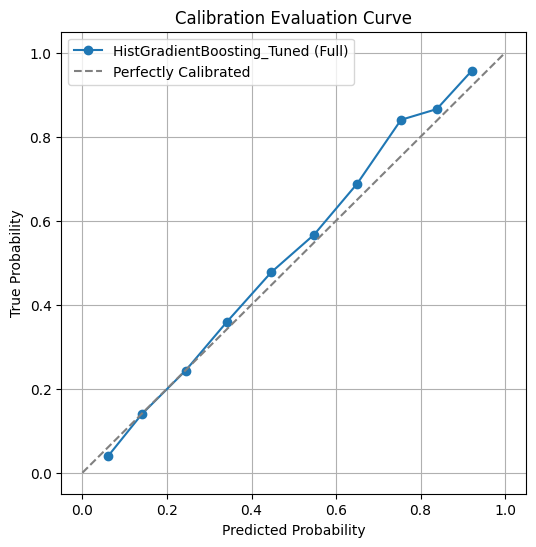

In [38]:
prob_true, prob_pred = calibration_curve(y_test, y_test_prob_full, n_bins=10)
plt.figure(figsize=(6, 6))
plt.plot(prob_pred, prob_true, marker='o', label=f"{best_model_name} (Full)")
plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Perfectly Calibrated')
plt.xlabel('Predicted Probability')
plt.ylabel('True Probability')
plt.title('Calibration Evaluation Curve')
plt.legend()
plt.grid(True)
plt.show()

## SECTION 13 � BUSINESS LIFT ANALYSIS

In [39]:
df_lift = pd.DataFrame({'true': y_test, 'prob': y_test_prob_full})
df_lift = df_lift.sort_values('prob', ascending=False).reset_index(drop=True)
total_purchasers = df_lift['true'].sum()
random_rate = df_lift['true'].mean()

lift_results = []
for p in [0.01, 0.05, 0.10, 0.20, 0.30]:
    k = int(len(df_lift) * p)
    top_k = df_lift.head(k)
    purchasers_found = top_k['true'].sum()
    purchase_rate = purchasers_found / k
    lift = purchase_rate / random_rate
    capture_rate = purchasers_found / total_purchasers
    
    lift_results.append({
        'Top %': f"{p*100:.0f}%",
        'Customers Targeted': k,
        'Actual Purchasers': purchasers_found,
        'Purchase Rate': purchase_rate,
        'Lift': lift,
        'Capture Rate': capture_rate
    })

lift_df = pd.DataFrame(lift_results)
display(lift_df)


,Top %,Customers Targeted,Actual Purchasers,Purchase Rate,Lift,Capture Rate
0,1%,154,144,0.935065,5.263791,0.052536
1,5%,771,604,0.783398,4.410009,0.220358
2,10%,1543,1000,0.648088,3.648304,0.364830
3,20%,3086,1519,0.492223,2.770887,0.554177
4,30%,4629,1876,0.405271,2.281406,0.684422


## SECTION 14 � FEATURE IMPORTANCE

In [40]:
# Extract model from pipeline if needed
model_for_importance = final_model.named_steps['classifier'] if hasattr(final_model, 'named_steps') else final_model

if hasattr(model_for_importance, 'feature_importances_'):
    importances = model_for_importance.feature_importances_
    feat_imp = pd.DataFrame({'Feature': features, 'Importance': importances})
    feat_imp = feat_imp.sort_values('Importance', ascending=False)
    display(feat_imp.head(10))
elif hasattr(model_for_importance, 'coef_'):
    importances = model_for_importance.coef_[0]
    feat_imp = pd.DataFrame({'Feature': features, 'Importance': np.abs(importances), 'Direction': np.sign(importances)})
    feat_imp = feat_imp.sort_values('Importance', ascending=False)
    display(feat_imp.head(10))
else:
    print("Feature importance not natively available for this model type.")


Feature importance not natively available for this model type.


## SECTION 15 � ERROR ANALYSIS

In [41]:
df_errors = df_test.copy()
df_errors['prob'] = y_test_prob_full
df_errors['pred'] = y_test_pred_full
df_errors['true'] = y_test

df_errors['ErrorType'] = 'True Negative'
df_errors.loc[(df_errors['true'] == 1) & (df_errors['pred'] == 1), 'ErrorType'] = 'True Positive'
df_errors.loc[(df_errors['true'] == 0) & (df_errors['pred'] == 1), 'ErrorType'] = 'False Positive'
df_errors.loc[(df_errors['true'] == 1) & (df_errors['pred'] == 0), 'ErrorType'] = 'False Negative'

print(df_errors.groupby('ErrorType')[['FEATURE_recency_days', 'FEATURE_total_gross_purchase_spend', 'prob']].mean())


                FEATURE_recency_days  FEATURE_total_gross_purchase_spend  \
ErrorType                                                                  
False Negative            102.898366                         2427.796081   
False Positive             21.466887                         9472.612728   
True Negative             220.103496                         1289.566729   
True Positive              17.547893                        19890.857443   

                    prob  
ErrorType                 
False Negative  0.234905  
False Positive  0.623675  
True Negative   0.129995  
True Positive   0.706652  


## SECTION 18 � EXPERIMENT REPORT

In [42]:
report = {
    'Experiment': '30-Day Next-Purchase Prediction',
    'Target': TARGET,
    'Feature Count': len(features),
    'Training Rows': len(X_train),
    'Validation Rows': len(X_val),
    'Test Rows': len(X_test),
    'Validation Metrics': val_metrics_df.to_dict(orient='index'),
    'Selected Model': best_model_name,
    'Model Selection Rationale': f"Selected {best_model_name} as best model amongst evaluated candidates based on max PR-AUC on Validation Set. This is a baseline comparative experiment, not exhaustive.",
    'Final Test Metrics (Full Feature)': full_test_metrics,
    'Final Test Metrics (RFM)': rfm_test_metrics,
    'RFM vs Full Deltas': comparison_df.loc['Delta'].to_dict(),
    'Lift Analysis': lift_results,
    'Calibration Metrics': {
        'Brier Score (Test)': full_test_metrics['Brier Score']
    },
    'Feature Importance Summary': feat_imp.head(5).to_dict(orient='records') if 'feat_imp' in locals() else None,
    'Error Analysis Summary': df_errors.groupby('ErrorType').size().to_dict()
}

with open(EXP_DIR / 'evaluation_report.json', 'w') as f:
    json.dump(report, f, indent=4)
    
df_errors.to_parquet(EXP_DIR / 'predictions.parquet', index=False)
if 'feat_imp' in locals():
    feat_imp.to_parquet(EXP_DIR / 'feature_importance.parquet', index=False)
print("Experiment report saved.")


TypeError: Object of type int64 is not JSON serializable

## SECTION 19 � EXPERIMENTAL MODEL ARTIFACT POLICY
Note: Experimental artifact is deliberately saved locally within `backend/training/experiments/next_purchase_30d/`.
It is NOT pushed to `backend/models/` to strictly separate experimentation from production.
**Experimental model � not production approved.**


In [43]:
joblib.dump(final_model, EXP_DIR / f'model_{best_model_name.replace(" ", "_")}.pkl')
print("Model saved to experiment directory. Experimental model � not production approved.")


Model saved to experiment directory. Experimental model � not production approved.


## SECTION 20 � DATA LEAKAGE SAFETY

In [44]:
leakage_failed = False
if any(col.startswith('TARGET_') for col in X_train.columns): leakage_failed = True
if 'split' in X_train.columns: leakage_failed = True
if 'customer_id' in X_train.columns: leakage_failed = True
if 'observation_date' in X_train.columns: leakage_failed = True

# Double check test sets weren't used in training process conceptually
# (asserts verify features used for modeling don't contain any target info/ids)

if not leakage_failed:
    print("MODEL_LEAKAGE_STATUS = PASS")
else:
    print("MODEL_LEAKAGE_STATUS = FAIL")


MODEL_LEAKAGE_STATUS = PASS
